# Web Scraping — Canciones más escuchadas en Spotify

En este proyecto vamos a extraer datos de una página web real (Wikipedia), limpiarlos, guardarlos en una base de datos SQLite y visualizarlos con gráficas.

**Flujo del proyecto:**
```
Wikipedia (HTML) → requests → pandas.read_html() → DataFrame limpio → SQLite → Gráficas
```

---
## PASO 1 — Importar las librerías

Antes de hacer cualquier cosa, importamos todas las librerías que vamos a necesitar:

- `requests` → para hacer la petición HTTP y descargar el HTML de la web
- `BeautifulSoup` → para leer y navegar el HTML como si fuera un árbol de elementos
- `StringIO` → convierte texto plano en un objeto que pandas puede leer directamente
- `pandas` → para organizar los datos en una tabla (DataFrame)
- `sqlite3` → para guardar los datos en una base de datos local (viene incluido en Python)
- `matplotlib` y `seaborn` → para crear gráficas

In [2]:
import requests
from bs4 import BeautifulSoup
from io import StringIO
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

print('Librerías importadas correctamente ✓')

Librerías importadas correctamente ✓


---
## PASO 2 — Descargar el HTML de Wikipedia

Usamos `requests.get()` para hacer una petición HTTP GET a la URL.

**¿Qué son las cabeceras (headers)?**  
Cuando tu navegador pide una página web, envía información sobre quién es (el 'User-Agent'). Wikipedia bloquea las peticiones que no tienen estas cabeceras porque parecen bots maliciosos. Añadiendo el `User-Agent` simulamos ser un navegador normal y Wikipedia nos responde con el HTML.

- `response.status_code` → 200 significa éxito. 403 significa bloqueado. 404 significa no encontrado.
- `response.text` → el HTML completo de la página como texto

In [3]:
# URL de la página de Wikipedia que queremos scrapear
url = 'https://en.wikipedia.org/wiki/List_of_most-streamed_songs_on_Spotify'

# Cabeceras HTTP que simulan ser un navegador real
# Sin esto, Wikipedia devuelve error 403 (Forbidden)
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

# Hacemos la petición HTTP GET enviando también las cabeceras
response = requests.get(url, headers=headers)

# Comprobamos que la petición fue correcta (200 = OK)
print(f'Código de respuesta: {response.status_code}')
print(f'Tamaño del HTML descargado: {len(response.text)} caracteres')
print('\nPrimeros 300 caracteres del HTML:')
print(response.text[:300])

Código de respuesta: 200
Tamaño del HTML descargado: 688354 caracteres

Primeros 300 caracteres del HTML:
<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disab


---
## PASO 3 — Extraer la tabla del HTML

Wikipedia tiene muchas tablas en esta página (26 en total). Necesitamos la primera, que tiene las columnas: `Rank`, `Song`, `Artist(s)`, `Streams (billions)`, `Release date`.

**¿Cómo funciona este proceso?**
1. `BeautifulSoup` analiza todo el HTML y lo convierte en un árbol de elementos navegable
2. `find_all('table')` encuentra todas las etiquetas `<table>` del HTML
3. Tomamos la primera tabla (índice `[0]`) que es el ranking principal
4. `pd.read_html()` convierte esa tabla HTML en un DataFrame de pandas automáticamente
5. `StringIO` es necesario porque `pd.read_html()` espera un objeto de tipo archivo, no texto puro

In [4]:
# Analizamos el HTML completo con BeautifulSoup
soup = BeautifulSoup(response.text, 'lxml')

# Encontramos todas las tablas del HTML
todas_las_tablas = soup.find_all('table')
print(f'Total de tablas encontradas en la página: {len(todas_las_tablas)}')

# La primera tabla (índice 0) es el ranking de canciones más escuchadas
tabla_principal = todas_las_tablas[0]

# Convertimos esa tabla HTML en un DataFrame de pandas
# StringIO convierte el texto HTML de la tabla en un objeto que pd.read_html() puede leer
df = pd.read_html(StringIO(str(tabla_principal)))[0]

print(f'\nColumnas de la tabla: {df.columns.tolist()}')
print(f'Filas encontradas: {len(df)}')
print('\nPrimeras 5 filas:')
df.head()

Total de tablas encontradas en la página: 26

Columnas de la tabla: ['Rank', 'Song', 'Artist(s)', 'Streams (billions)', 'Release date', 'Ref.']
Filas encontradas: 101

Primeras 5 filas:


,Rank,Song,Artist(s),Streams (billions),Release date,Ref.
0,1,"""Blinding Lights""",The Weeknd,5.358,29 November 2019,[1]
1,2,"""Shape of You""",Ed Sheeran,4.852,6 January 2017,[2]
2,3,"""Sweater Weather""",The Neighbourhood,4.511,3 December 2012,[3]
3,4,"""Starboy""",The Weeknd and Daft Punk,4.465,21 September 2016,[4]
4,5,"""As It Was""",Harry Styles,4.342,1 April 2022,[5]


---
## PASO 4 — Limpiar y procesar el DataFrame

Los datos vienen bien estructurados pero necesitamos:

1. **Eliminar la columna `Ref.`** — son referencias de Wikipedia que no necesitamos
2. **Renombrar las columnas** al español para que sean más claras
3. **Eliminar filas vacías** (NaN) si las hubiera
4. **Convertir `streams` a número** — aunque ya viene como decimal, lo verificamos
5. **Resetear el índice** para que empiece limpio desde 0

In [5]:
# Inspeccionamos los tipos de dato de cada columna
print('Tipos de dato por columna:')
print(df.dtypes)
print('\nFilas con valores vacíos por columna:')
print(df.isnull().sum())

Tipos de dato por columna:
Rank                  str
Song                  str
Artist(s)             str
Streams (billions)    str
Release date          str
Ref.                  str
dtype: object

Filas con valores vacíos por columna:
Rank                  0
Song                  0
Artist(s)             0
Streams (billions)    0
Release date          0
Ref.                  2
dtype: int64


In [6]:
# Eliminamos la columna 'Ref.' — solo contiene referencias bibliográficas de Wikipedia
df = df.drop(columns=['Ref.'])

# Renombramos las columnas con nombres simples en español
df.columns = ['ranking', 'cancion', 'artista', 'streams_miles_millones', 'fecha_publicacion']

# Eliminamos filas que tengan algún valor vacío (NaN)
df = df.dropna()

# Nos aseguramos de que streams sea un número decimal (float)
# errors='coerce' convierte en NaN los valores que no se puedan convertir
df['streams_miles_millones'] = pd.to_numeric(df['streams_miles_millones'], errors='coerce')

# Eliminamos cualquier fila que haya quedado con NaN después de la conversión
df = df.dropna(subset=['streams_miles_millones'])

# Reseteamos el índice para que empiece en 0 de forma limpia
df = df.reset_index(drop=True)

print(f'Total de canciones en el dataset limpio: {len(df)}')
print('\nTipos de dato tras la limpieza:')
print(df.dtypes)
print('\nPrimeras 10 canciones:')
df.head(10)

Total de canciones en el dataset limpio: 100

Tipos de dato tras la limpieza:
ranking                       str
cancion                       str
artista                       str
streams_miles_millones    float64
fecha_publicacion             str
dtype: object

Primeras 10 canciones:


,ranking,cancion,artista,streams_miles_millones,fecha_publicacion
0,1,"""Blinding Lights""",The Weeknd,5.358,29 November 2019
1,2,"""Shape of You""",Ed Sheeran,4.852,6 January 2017
2,3,"""Sweater Weather""",The Neighbourhood,4.511,3 December 2012
3,4,"""Starboy""",The Weeknd and Daft Punk,4.465,21 September 2016
4,5,"""As It Was""",Harry Styles,4.342,1 April 2022
5,6,"""Someone You Loved""",Lewis Capaldi,4.281,8 November 2018
6,7,"""Sunflower""",Post Malone and Swae Lee,4.191,18 October 2018
7,8,"""One Dance""",Drake with Wizkid and Kyla,4.150,5 April 2016
8,9,"""Perfect""",Ed Sheeran,3.904,3 March 2017
9,10,"""Stay""",The Kid Laroi with Justin Bieber,3.849,27 July 2021


In [7]:
# Estadísticas básicas de los streams
print('Estadísticas de los streams (en miles de millones):')
print(df['streams_miles_millones'].describe())
print(f'\nCanción más escuchada: {df.loc[df["streams_miles_millones"].idxmax(), "cancion"]} ({df["streams_miles_millones"].max()} mil millones)')
print(f'Canción menos escuchada: {df.loc[df["streams_miles_millones"].idxmin(), "cancion"]} ({df["streams_miles_millones"].min()} mil millones)')

Estadísticas de los streams (en miles de millones):
count    100.00000
mean       3.18440
std        0.53084
min        2.56400
25%        2.81150
50%        3.05750
75%        3.41575
max        5.35800
Name: streams_miles_millones, dtype: float64

Canción más escuchada: "Blinding Lights" (5.358 mil millones)
Canción menos escuchada: "One of the Girls" (2.564 mil millones)


---
## PASO 5 — Guardar los datos en SQLite

SQLite es una base de datos que se guarda en un **archivo local** (fichero `.db`). No necesita servidor ni configuración externa, por eso es ideal para proyectos pequeños y de aprendizaje.

**Flujo para usar SQLite:**
1. `sqlite3.connect('archivo.db')` → crea el archivo si no existe, o lo abre si ya existe
2. `df.to_sql()` → crea la tabla y la rellena con los datos del DataFrame automáticamente
3. `con.commit()` → guarda permanentemente los cambios en el archivo
4. `pd.read_sql_query()` → ejecuta una consulta SQL y devuelve el resultado como DataFrame
5. `con.close()` → cerramos la conexión cuando terminamos (buena práctica siempre)

In [8]:
# Creamos (o abrimos si ya existe) el archivo de base de datos
con = sqlite3.connect('spotify_scraping.db')

# to_sql() convierte el DataFrame directamente en una tabla SQL
# name='canciones'  → nombre de la tabla dentro de la base de datos
# if_exists='replace' → si la tabla ya existe, la borra y la crea de nuevo (evita duplicados)
# index=False → no guardamos el índice del DataFrame como columna extra
df.to_sql(name='canciones', con=con, if_exists='replace', index=False)

# Guardamos los cambios en el archivo .db
con.commit()

print('Datos guardados en spotify_scraping.db ✓')

# Verificamos que los datos se guardaron correctamente haciendo un SELECT
print('\nVerificación — primeras 5 filas leídas directamente desde la base de datos:')
pd.read_sql_query('SELECT * FROM canciones LIMIT 5', con)

Datos guardados en spotify_scraping.db ✓

Verificación — primeras 5 filas leídas directamente desde la base de datos:


,ranking,cancion,artista,streams_miles_millones,fecha_publicacion
0,1,"""Blinding Lights""",The Weeknd,5.358,29 November 2019
1,2,"""Shape of You""",Ed Sheeran,4.852,6 January 2017
2,3,"""Sweater Weather""",The Neighbourhood,4.511,3 December 2012
3,4,"""Starboy""",The Weeknd and Daft Punk,4.465,21 September 2016
4,5,"""As It Was""",Harry Styles,4.342,1 April 2022


In [9]:
# Ejemplo de consulta SQL: las 5 canciones con más streams
# ORDER BY ... DESC → ordena de mayor a menor
# LIMIT 5 → solo devuelve las 5 primeras
print('Top 5 canciones más escuchadas (consulta SQL directa):')
pd.read_sql_query(
    'SELECT ranking, cancion, artista, streams_miles_millones FROM canciones ORDER BY streams_miles_millones DESC LIMIT 5',
    con
)

Top 5 canciones más escuchadas (consulta SQL directa):


,ranking,cancion,artista,streams_miles_millones
0,1,"""Blinding Lights""",The Weeknd,5.358
1,2,"""Shape of You""",Ed Sheeran,4.852
2,3,"""Sweater Weather""",The Neighbourhood,4.511
3,4,"""Starboy""",The Weeknd and Daft Punk,4.465
4,5,"""As It Was""",Harry Styles,4.342


---
## PASO 6 — Visualizar los datos

Creamos **3 gráficas** para explorar visualmente los datos:

1. **Barras horizontales** — Top 10 canciones con más streams
2. **Histograma** — Distribución de streams de todas las canciones (ver cómo se reparte la popularidad)
3. **Barras verticales** — Top 10 artistas con más canciones en el ranking

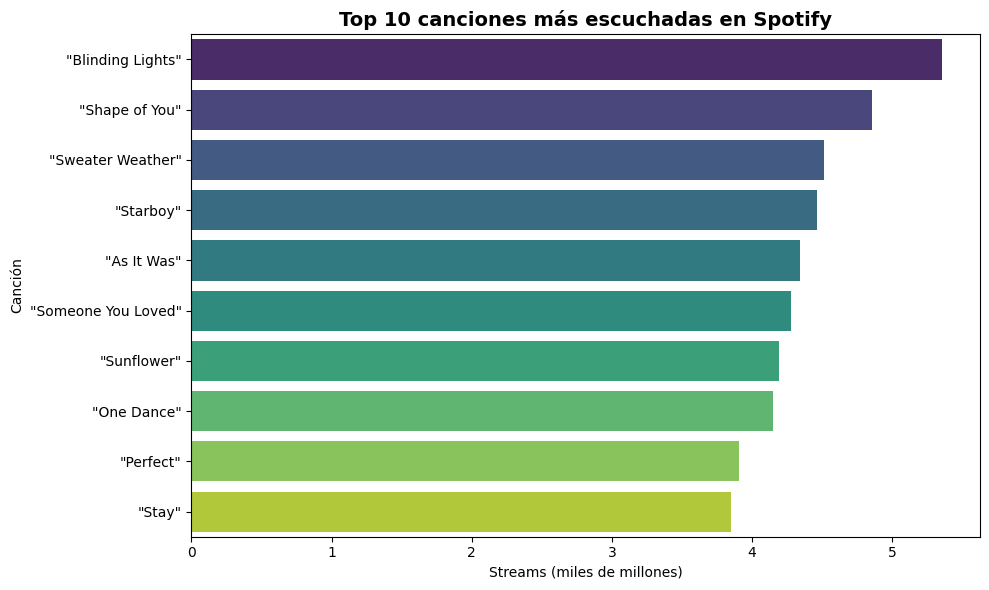

In [10]:
# --- GRÁFICA 1: Top 10 canciones más escuchadas (barras horizontales) ---

# nlargest(10, columna) selecciona las 10 filas con el valor más alto en esa columna
top10 = df.nlargest(10, 'streams_miles_millones')

plt.figure(figsize=(10, 6))  # tamaño de la figura en pulgadas (ancho x alto)

# barplot con y='cancion' (eje vertical) y x='streams' (eje horizontal) = barras horizontales
# palette='viridis' → paleta de colores
sns.barplot(data=top10, x='streams_miles_millones', y='cancion', palette='viridis', hue='cancion', legend=False)

plt.title('Top 10 canciones más escuchadas en Spotify', fontsize=14, fontweight='bold')
plt.xlabel('Streams (miles de millones)')
plt.ylabel('Canción')
plt.tight_layout()  # ajusta los márgenes para que no se corten las etiquetas
plt.show()

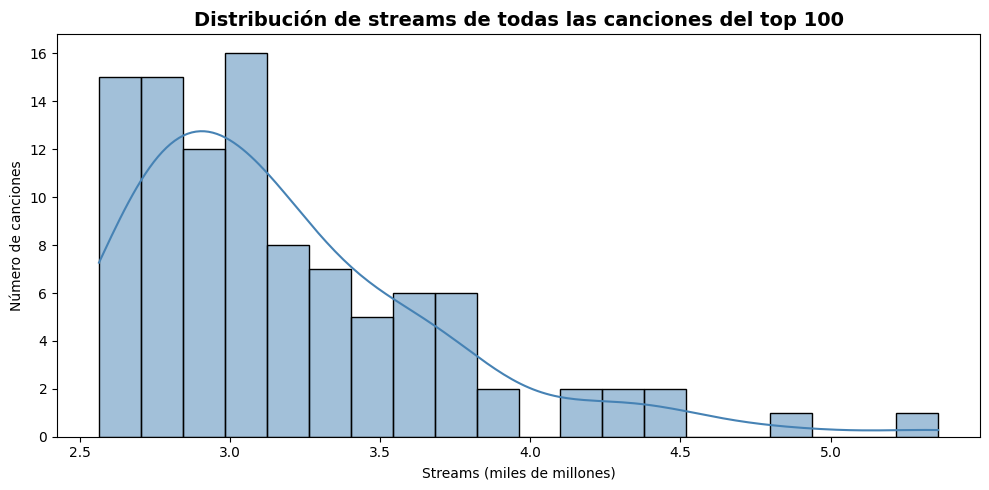

In [11]:
# --- GRÁFICA 2: Histograma — distribución de streams ---

# Un histograma agrupa los valores en rangos (bins) y muestra cuántas canciones
# caen en cada rango. Sirve para entender cómo se distribuye la popularidad:
# ¿hay muchas canciones con pocos streams y pocas con muchos? (distribución sesgada)

plt.figure(figsize=(10, 5))

# bins=20 → divide el rango de valores en 20 grupos
# kde=True → añade una curva de densidad suavizada encima de las barras
sns.histplot(df['streams_miles_millones'], bins=20, kde=True, color='steelblue')

plt.title('Distribución de streams de todas las canciones del top 100', fontsize=14, fontweight='bold')
plt.xlabel('Streams (miles de millones)')
plt.ylabel('Número de canciones')
plt.tight_layout()
plt.show()

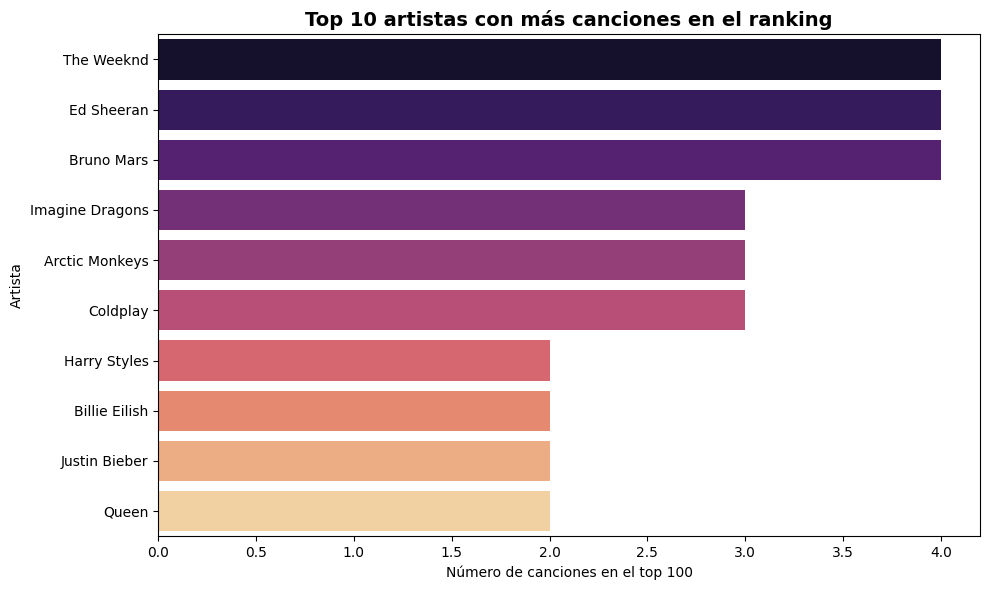

In [12]:
# --- GRÁFICA 3: Top 10 artistas con más canciones en el ranking ---

# value_counts() cuenta cuántas veces aparece cada artista en la columna
# y los ordena de mayor a menor automáticamente
# .head(10) se queda solo con los 10 primeros
artistas_top = df['artista'].value_counts().head(10)

plt.figure(figsize=(10, 6))

# Aquí ponemos los valores (número de canciones) en x y los artistas en y
sns.barplot(x=artistas_top.values, y=artistas_top.index, palette='magma', hue=artistas_top.index, legend=False)

plt.title('Top 10 artistas con más canciones en el ranking', fontsize=14, fontweight='bold')
plt.xlabel('Número de canciones en el top 100')
plt.ylabel('Artista')
plt.tight_layout()
plt.show()

In [13]:
# Cerramos la conexión a la base de datos — siempre hay que hacerlo al terminar
con.close()
print('Conexión a la base de datos cerrada ✓')
print('\n¡Proyecto completo! ✓')

Conexión a la base de datos cerrada ✓

¡Proyecto completo! ✓
